In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import io
from PIL import Image
import glob
import os
import pandas as pd
import matplotlib
import re
import seaborn as sns
import sys
from datetime import datetime, timedelta
sys.path.append('/Users/ang/Seafile/BSc_code/')

from functions import *
import h5py
import pingouin as pg
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import linregress
import scipy.stats as stats
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
import itertools
import statsmodels.stats.multicomp as mc
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Main processing loop for multiple files
pc = 'sophia'
if pc == 'sophia':
    basevol='C:/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'
else:
    basevol = '/Users/ang/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'

In [3]:
df = pd.read_hdf(output_folder + "final_sharks.h5", key='sharks')
df.head()

,index,SPEED#wcentroid,ID,X#pcentroid,Y#pcentroid,ANGLE,frame,time,headx,heady,...,normalized_nnd,mean_body_length,body_length,standardized_speed,tailbeat_frequency,tailbeat_amplitude,standardized_amplitude,strouhal_number,Trial_num,events
0,0,0.000000,0,NaN,NaN,-0.263183,0,0.00,2044.00,685.000000,...,0.754182,168.769768,177.037783,NaN,1.020408,73.417593,0.414700,NaN,0,0
1,1,55.754349,0,NaN,NaN,-0.253584,1,0.01,2045.00,685.000000,...,0.751215,168.968342,177.447051,NaN,1.020408,73.417593,0.413744,NaN,0,0
2,2,103.976613,0,NaN,NaN,-0.245468,2,0.02,2046.00,684.333333,...,0.751158,168.964560,177.425603,NaN,1.020408,73.417593,0.413794,NaN,0,0
3,3,123.176350,0,NaN,NaN,-0.238684,3,0.03,2047.75,684.000000,...,0.747436,169.092242,177.486965,NaN,1.020408,73.417593,0.413651,NaN,0,0
4,4,126.865948,0,NaN,NaN,-0.233522,4,0.04,2049.20,683.800000,...,0.743690,169.239818,176.966319,NaN,1.020408,73.417593,0.414868,NaN,0,0


### Test

In [4]:
df_exp = df[(df['Trial'] == 'sequence_20240303_060726300_DJI_0242') & (df['frame'].between(29000, 32000)) & (df['ID'] != 4)]
df_exp.head()

,index,SPEED#wcentroid,ID,X#pcentroid,Y#pcentroid,ANGLE,frame,time,headx,heady,...,normalized_nnd,mean_body_length,body_length,standardized_speed,tailbeat_frequency,tailbeat_amplitude,standardized_amplitude,strouhal_number,Trial_num,events
92117,29000,208.710503,0,NaN,NaN,-2.375963,29000,579.930000,4523.375,2362.875,...,4.447896,214.106570,213.495690,0.926688,1.191016,72.327244,0.338776,0.435409,0,0
92118,29001,219.858030,0,NaN,NaN,-2.395071,29001,579.950005,4519.250,2361.250,...,4.427993,214.853872,214.256339,0.927340,1.191016,72.327244,0.337573,0.433558,0,0
92119,29002,226.920933,0,NaN,NaN,-2.415603,29002,579.970001,4515.000,2359.625,...,4.409245,215.569194,215.130670,0.929816,1.202361,72.902912,0.338877,0.438208,0,0
92120,29003,226.872120,0,NaN,NaN,-2.435625,29003,579.989998,4511.125,2358.000,...,4.400001,215.922592,215.743542,0.925868,1.202361,72.902912,0.337915,0.438826,0,0
92121,29004,234.988861,0,NaN,NaN,-2.457572,29004,580.010002,4507.250,2356.500,...,4.389020,216.308262,216.232871,0.922327,1.202361,72.902912,0.337150,0.439514,0,0


#### Correlation with heading

In [5]:
#def make_velocity_vectors(df, heading_col="heading", speed_col="standardized_speed", deg=True):
    """
    Adds 'vx','vy' columns to df and returns df copy.
    heading in degrees by default (set deg=False if already in radians).
    """
    df = df.copy()
    # heading is already in radians, so no conversion needed
    df["vx"] = df[speed_col].values * np.cos(df[heading_col].values)
    df["vy"] = df[speed_col].values * np.sin(df[heading_col].values)
    return df


def _cosine_normalize(v):
    norm = np.linalg.norm(v, axis=1, keepdims=True)
    # avoid division by zero
    norm[norm == 0] = np.nan
    return v / norm

def pairwise_velocity_correlation(df_trial,
                                  focal_id,
                                  other_id,
                                  frame_col="frame",
                                  max_shift=100,
                                  normalize=False):
    """
    Compute C(tau) = mean_t [ v_focal(t) · v_other(t + tau) ]
    for tau in [-max_shift .. +max_shift].
    Returns a pandas Series indexed by tau.
    - df_trial: DataFrame for a single trial with columns ['ID', frame_col, 'vx','vy'] (or heading/speed to precompute)
    - normalize: if True compute cosine similarity (normalize vectors before dot).
    """
    # Subset and index by frame for fast lookup
    A = df_trial[df_trial["ID"] == focal_id][[frame_col, "vx", "vy"]].set_index(frame_col).sort_index()
    B = df_trial[df_trial["ID"] == other_id][[frame_col, "vx", "vy"]].set_index(frame_col).sort_index()

    if A.empty or B.empty:
        taus = range(-max_shift, max_shift + 1)
        return pd.Series(index=taus, data=np.nan, name=f"{focal_id}_vs_{other_id}")

    # Convert to numpy arrays with frame indices
    frames_A = A.index.values
    frames_B = B.index.values

    # Option: precompute numpy arrays aligned by frame when shifted
    taus = list(range(-max_shift, max_shift + 1))
    results = []
    for tau in taus:
        dots = []
        # We want t in frames_A such that t+tau exists in frames_B
        target_frames = frames_A + tau
        # Find intersection efficiently using set membership (for moderate sizes ok)
        # Create mask where t+tau is in frames_B
        mask = np.isin(target_frames, frames_B)
        if not np.any(mask):
            results.append(np.nan)
            continue

        valid_t = frames_A[mask]
        valid_t_shift = valid_t + tau

        # fetch vectors
        vA = A.loc[valid_t].to_numpy()  # shape (M,2)
        vB = B.loc[valid_t_shift].to_numpy()

        if normalize:
            vA = _cosine_normalize(vA)
            vB = _cosine_normalize(vB)
            # after normalization some rows may be NaN (zero-length vectors) -> drop
            valid_mask = ~np.isnan(vA).any(axis=1) & ~np.isnan(vB).any(axis=1)
            if not np.any(valid_mask):
                results.append(np.nan)
                continue
            vA = vA[valid_mask]
            vB = vB[valid_mask]

        # dot product for each valid pair
        dots = np.einsum("ij,ij->i", vA, vB)
        results.append(dots.mean() if len(dots) else np.nan)

    return pd.Series(data=results, index=taus, name=f"{focal_id}_vs_{other_id}")

def compute_all_focals(df_trial, max_shift=100, normalize=False, frame_col="frame"):
    """
    For one trial DataFrame with multiple IDs, compute pairwise C(tau) for each focal ID vs every other ID.
    Returns:
      - pairwise: dict keyed by (focal_id, other_id) -> pd.Series(C(tau))
      - mean_by_focal: dict keyed by focal_id -> pd.Series(mean C(tau) across other IDs)
    """
    ids = df_trial["ID"].unique()
    pairwise = {}
    mean_by_focal = {}

    for fid in ids:
        series_list = []
        for oid in ids:
            if oid == fid:
                continue
            s = pairwise_velocity_correlation(df_trial, fid, oid, frame_col=frame_col,
                                              max_shift=max_shift, normalize=normalize)
            pairwise[(fid, oid)] = s
            series_list.append(s)

        # combine series_list into DataFrame and compute mean across columns (skip NaNs properly)
        if series_list:
            df_s = pd.concat(series_list, axis=1)
            mean_series = df_s.mean(axis=1, skipna=True)
        else:
            mean_series = pd.Series(index=range(-max_shift, max_shift+1), data=np.nan)
        mean_by_focal[fid] = mean_series

    return pairwise, mean_by_focal

df_exp = make_velocity_vectors(df_exp, heading_col="heading", speed_col="standardized_speed", deg=True)

# Then compute
#pairwise, mean_by_focal = compute_all_focals(df_exp, max_shift=200, normalize=False)


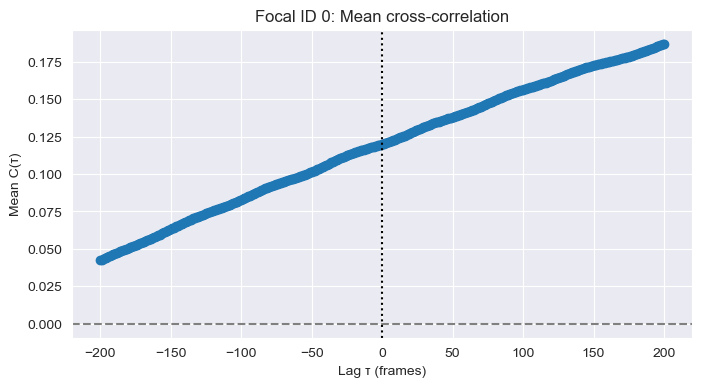

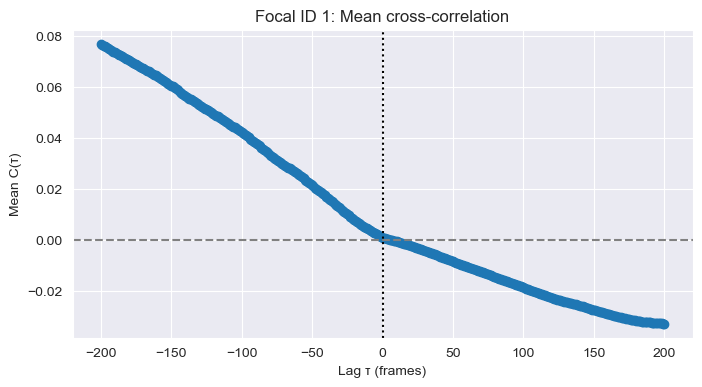

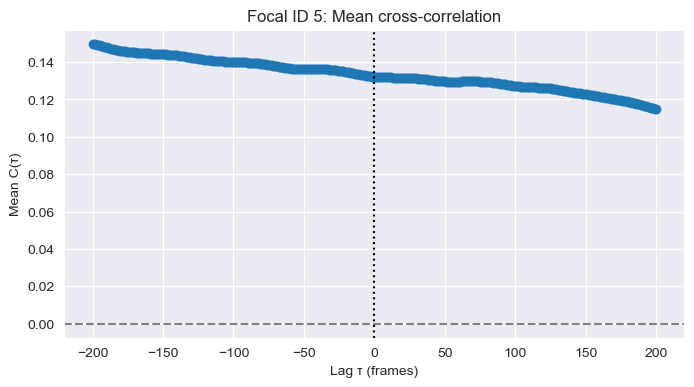

In [33]:
for focal, series in mean_by_focal.items():
    plt.figure(figsize=(8,4))
    plt.plot(series.index, series.values, marker='o')
    plt.axhline(0, color="gray", linestyle="--")
    plt.axvline(0, color="k", linestyle=":")
    plt.xlabel("Lag τ (frames)")
    plt.ylabel("Mean C(τ)")
    plt.title(f"Focal ID {focal}: Mean cross-correlation")
    plt.grid(True)
    plt.show()

In [6]:
def directional_correlation_vectorized_aligned(df_a, df_b, frame_col="frame", max_shift=100, window=50):
    """
    Compute windowed directional correlation for two IDs, aligned by frame numbers.
    """
    # Merge on frames with a lag for tau
    taus = np.arange(-max_shift, max_shift+1)
    results = []

    frames_a = df_a[frame_col].values
    va = df_a[["vx","vy"]].to_numpy()

    df_b_indexed = df_b.set_index(frame_col)

    for tau in taus:
        # Shift df_b by tau
        shifted_frames = frames_a + tau
        # Keep only frames that exist in df_b
        valid_mask = np.isin(shifted_frames, df_b_indexed.index)
        if not np.any(valid_mask):
            results.append(np.nan)
            continue

        va_valid = va[valid_mask]
        vb_valid = df_b_indexed.loc[shifted_frames[valid_mask], ["vx","vy"]].to_numpy()

        # Compute cosine similarity
        norm_va = np.linalg.norm(va_valid, axis=1)
        norm_vb = np.linalg.norm(vb_valid, axis=1)
        valid_vectors = (norm_va > 0) & (norm_vb > 0)
        if not np.any(valid_vectors):
            results.append(np.nan)
            continue

        cos_sim = np.sum(va_valid[valid_vectors] * vb_valid[valid_vectors], axis=1) / (norm_va[valid_vectors] * norm_vb[valid_vectors])
        # Windowed mean
        cos_sim_windowed = pd.Series(cos_sim).rolling(window=window, min_periods=1, center=True).mean().mean()
        results.append(cos_sim_windowed)

    return pd.DataFrame({"tau": taus, "correlation_windowed": results})

def multi_id_correlation_vectorized_aligned(df_trial, frame_col="frame", max_shift=100, window=50):
    ids = df_trial["ID"].unique()
    results = []

    for fid in ids:
        df_a = df_trial[df_trial["ID"] == fid].sort_values(frame_col)
        for oid in ids:
            if oid == fid:
                continue
            df_b = df_trial[df_trial["ID"] == oid].sort_values(frame_col)
            corr_df = directional_correlation_vectorized_aligned(df_a, df_b, frame_col=frame_col, max_shift=max_shift, window=window)
            corr_df["focal"] = fid
            corr_df["other"] = oid
            results.append(corr_df)

    return pd.concat(results, ignore_index=True)


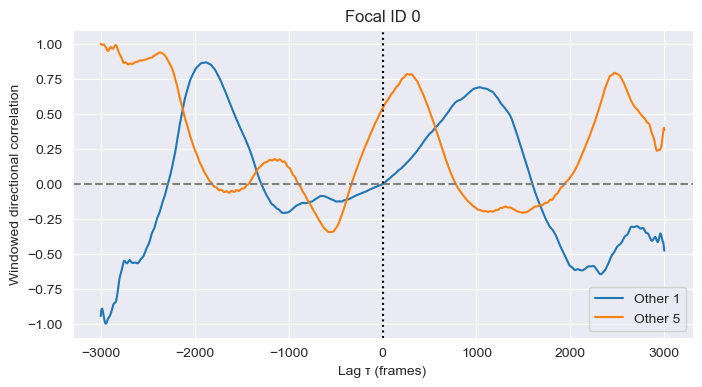

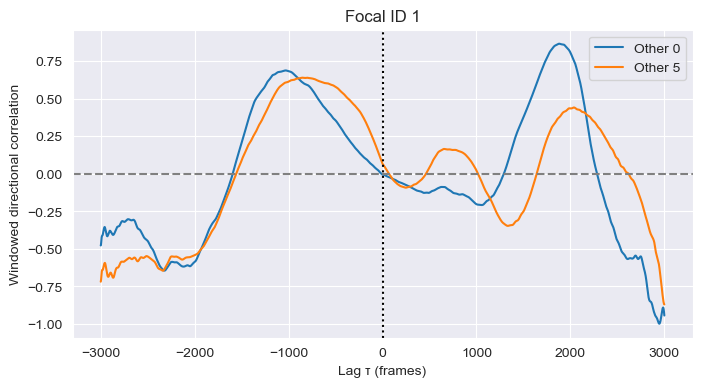

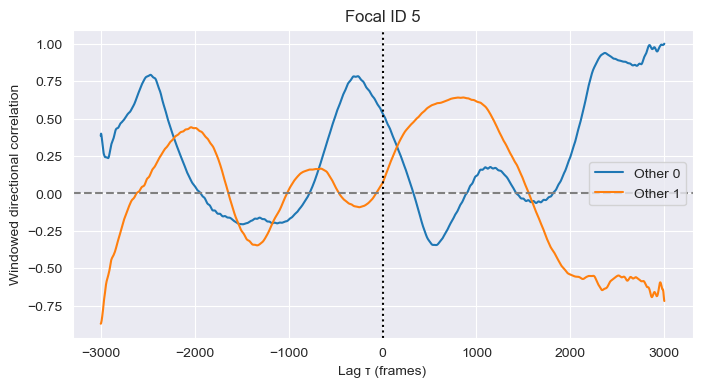

In [21]:
# df_exp should have ['ID','frame','vx','vy']
tau_df = multi_id_correlation_vectorized_aligned(df_exp, max_shift=5000, window=50)

# Plot example for one focal ID
import matplotlib.pyplot as plt
for fid in tau_df['focal'].unique():
    df_focal = tau_df[tau_df['focal'] == fid]
    plt.figure(figsize=(8,4))
    for oid in df_focal['other'].unique():
        df_pair = df_focal[df_focal['other'] == oid]
        plt.plot(df_pair['tau'], df_pair['correlation_windowed'], label=f"Other {oid}")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='k', linestyle=':')
    plt.xlabel("Lag τ (frames)")
    plt.ylabel("Windowed directional correlation")
    plt.title(f"Focal ID {fid}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [8]:
import numpy as np
import pandas as pd

def directional_correlation_windowed_simple(df_a, df_b, window=50, frame_col="frame"):
    """
    Compute per-frame cosine similarity between two IDs with a rolling window.

    Parameters
    ----------
    df_a, df_b : DataFrames with columns [frame_col, 'vx', 'vy']
    window : int, rolling window size
    frame_col : str, name of frame column

    Returns
    -------
    pd.DataFrame with columns ['frame', 'correlation_windowed']
    """
    # Align frames
    common_frames = np.intersect1d(df_a[frame_col], df_b[frame_col])
    if len(common_frames) == 0:
        return pd.DataFrame(columns=[frame_col, 'correlation_windowed'])

    va = df_a.set_index(frame_col).loc[common_frames, ["vx","vy"]].to_numpy()
    vb = df_b.set_index(frame_col).loc[common_frames, ["vx","vy"]].to_numpy()

    norm_va = np.linalg.norm(va, axis=1)
    norm_vb = np.linalg.norm(vb, axis=1)
    valid_mask = (norm_va > 0) & (norm_vb > 0)

    cos_sim = np.zeros(len(common_frames))
    cos_sim[valid_mask] = np.sum(va[valid_mask] * vb[valid_mask], axis=1) / (norm_va[valid_mask] * norm_vb[valid_mask])

    # Rolling window smoothing
    cos_sim_windowed = pd.Series(cos_sim, index=common_frames).rolling(window=window, min_periods=1, center=True).mean()

    return cos_sim_windowed.reset_index().rename(columns={0:'correlation_windowed', 'index': frame_col})


def multi_id_correlation_windowed_simple(df_trial, window=50, frame_col="frame"):
    """
    Compute windowed per-frame directional correlation for all focal IDs vs other IDs.
    Returns a DataFrame with columns ['frame', 'correlation_windowed', 'focal', 'other']
    """
    ids = df_trial["ID"].unique()
    results = []

    for fid in ids:
        df_a = df_trial[df_trial["ID"] == fid].sort_values(frame_col)
        for oid in ids:
            if oid == fid:
                continue
            df_b = df_trial[df_trial["ID"] == oid].sort_values(frame_col)
            corr_df = directional_correlation_windowed_simple(df_a, df_b, window=window, frame_col=frame_col)
            corr_df["focal"] = fid
            corr_df["other"] = oid
            results.append(corr_df)

    return pd.concat(results, ignore_index=True)



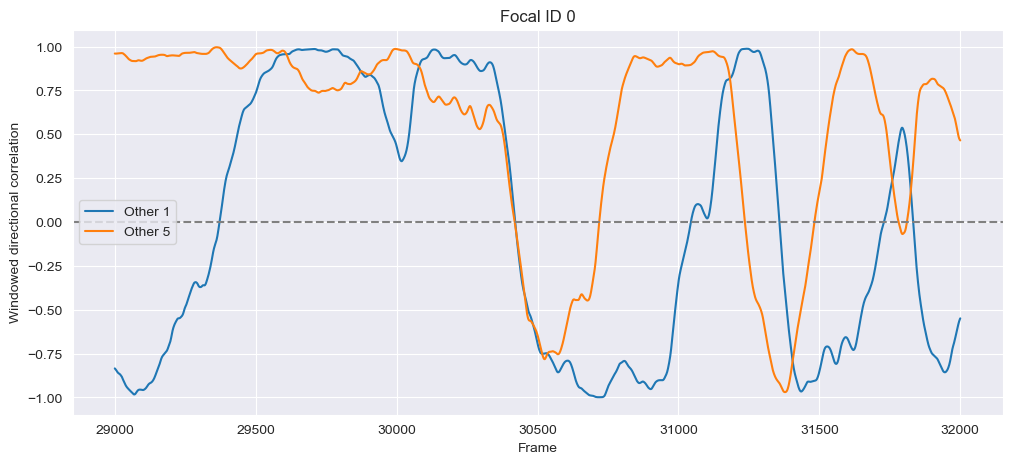

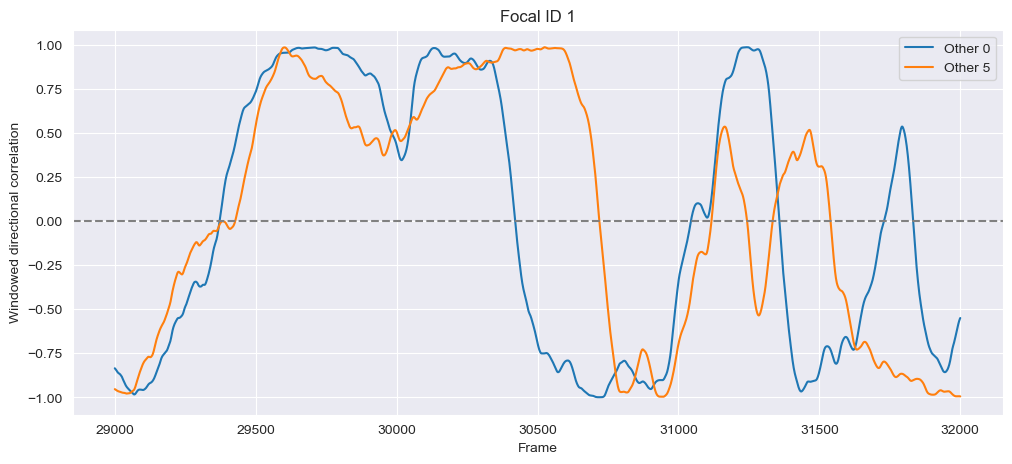

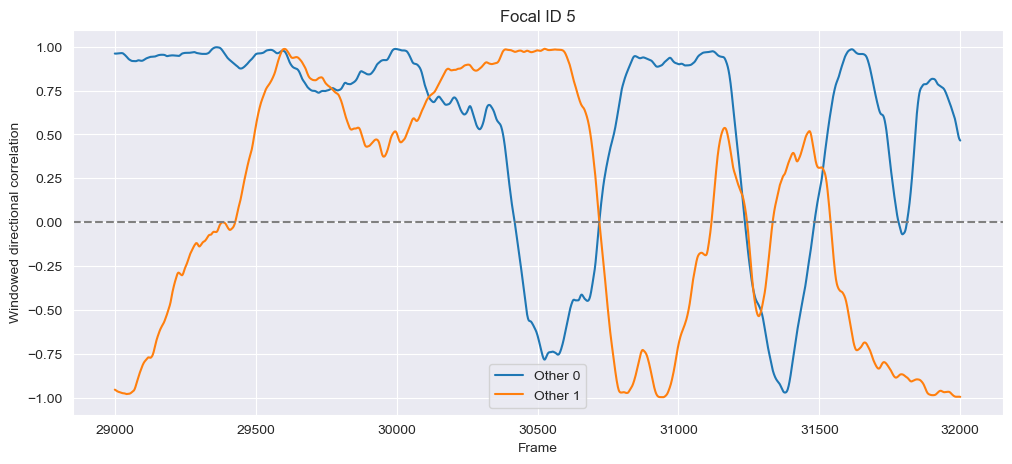

In [18]:
# Compute windowed per-frame correlations (50-frame window)
corr_df = multi_id_correlation_windowed_simple(df_exp, window=50, frame_col="frame")

# Plot per focal ID
for fid in corr_df['focal'].unique():
    df_focal = corr_df[corr_df['focal'] == fid]
    plt.figure(figsize=(12,5))

    for oid in df_focal['other'].unique():
        df_pair = df_focal[df_focal['other'] == oid].sort_values('frame')
        plt.plot(df_pair['frame'], df_pair['correlation_windowed'], label=f"Other {oid}")

    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Frame")
    plt.ylabel("Windowed directional correlation")
    plt.title(f"Focal ID {fid}")
    plt.legend()
    plt.grid(True)
    plt.show()


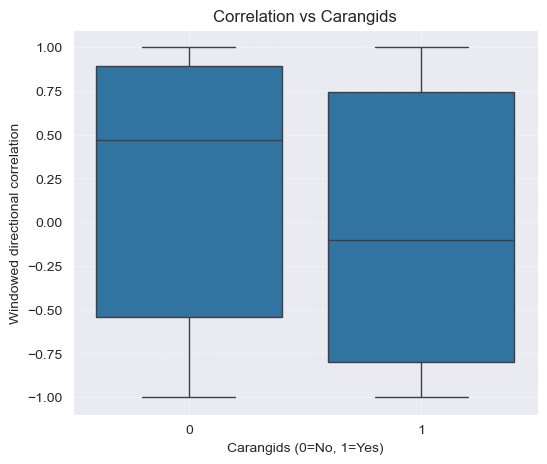

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge carangids info into corr_df (assuming carangids is per-frame)
df_plot = corr_df.merge(
    df_exp[['frame', 'carangids']].drop_duplicates(),
    on='frame',
    how='left'
)

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x='carangids', y='correlation_windowed', data=df_plot)
plt.xlabel("Carangids (0=No, 1=Yes)")
plt.ylabel("Windowed directional correlation")
plt.title("Correlation vs Carangids")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


##### hidden

In [34]:
import numpy as np
import pandas as pd

def directional_correlation_cosine(df_a, df_b, max_shift=100, point_col="frame"):
    """
    Compute cosine similarity C(t, τ) = dot(vA(t), vB(t+τ)) / (||vA|| * ||vB||)
    for each t in A and shift τ.

    Parameters
    ----------
    df_a : DataFrame with columns [point_col, 'vx','vy']
    df_b : DataFrame with columns [point_col, 'vx','vy']
    max_shift : int, maximum lag (τ)
    point_col : str, column used for aligning (e.g. 'frame')

    Returns
    -------
    DataFrame with columns [point_col, 'tau', 'correlation']
    """
    df_b = df_b.set_index(point_col)
    results = []

    for _, row_a in df_a.iterrows():
        t = row_a[point_col]
        va = np.array([row_a["vx"], row_a["vy"]])
        norm_va = np.linalg.norm(va)
        if norm_va == 0:
            continue  # skip zero vectors

        for tau in range(-max_shift, max_shift + 1):
            t_b = t + tau
            if t_b in df_b.index:
                row_b = df_b.loc[t_b]
                vb = np.array([row_b["vx"], row_b["vy"]])
                norm_vb = np.linalg.norm(vb)
                if norm_vb == 0:
                    continue
                cos_sim = np.dot(va, vb) / (norm_va * norm_vb)
                results.append({point_col: t, "tau": tau, "correlation": cos_sim})
            else:
                results.append({point_col: t, "tau": tau, "correlation": np.nan})

    return pd.DataFrame(results)

def multi_id_directional_correlation(df_trial, max_shift=2, point_col="frame"):
    """
    For a trial DataFrame with multiple IDs, compute directional correlation for each
    focal ID vs every other ID.

    Returns
    -------
    DataFrame with columns:
      ['focal', 'other', point_col, 'tau', 'correlation']
    """
    ids = df_trial["ID"].unique()
    results = []

    for fid in ids:
        df_a = df_trial[df_trial["ID"] == fid][[point_col, "vx", "vy"]]
        for oid in ids:
            if oid == fid:
                continue
            df_b = df_trial[df_trial["ID"] == oid][[point_col, "vx", "vy"]]
            corr_df = directional_correlation_cosine(df_a, df_b,
                                                     max_shift=max_shift,
                                                     point_col=point_col)
            corr_df["focal"] = fid
            corr_df["other"] = oid
            results.append(corr_df)

    return pd.concat(results, ignore_index=True)

corr_df = multi_id_directional_correlation(df_exp, max_shift=100, point_col="frame")


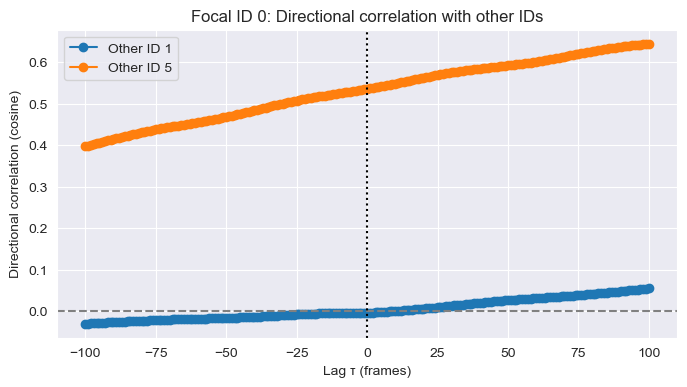

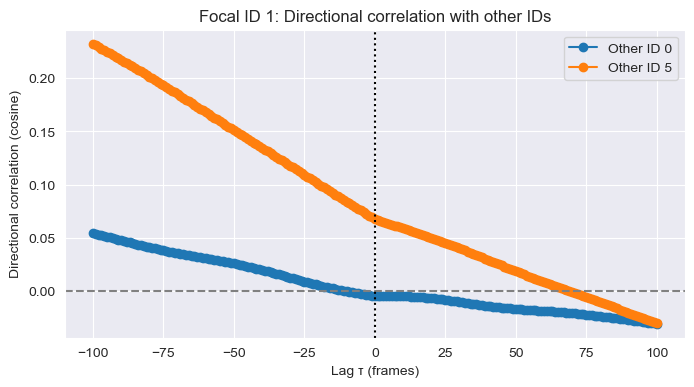

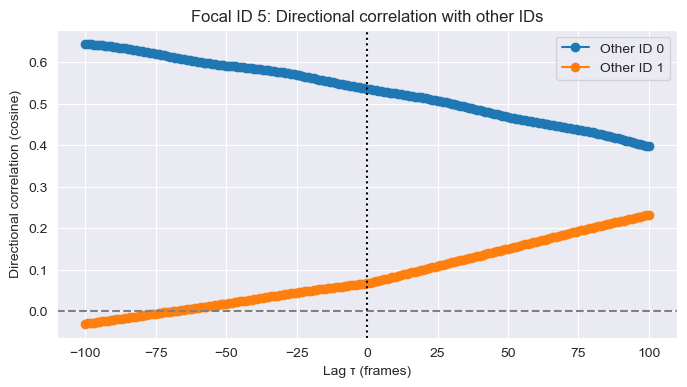

In [36]:
import matplotlib.pyplot as plt

# corr_df has columns: ['frame', 'tau', 'correlation', 'focal', 'other']

# Get list of unique focal IDs
focal_ids = corr_df['focal'].unique()

for fid in focal_ids:
    df_focal = corr_df[corr_df['focal'] == fid]

    plt.figure(figsize=(8, 4))
    # Plot each focal→other pair
    for oid in df_focal['other'].unique():
        df_pair = df_focal[df_focal['other'] == oid]
        # Aggregate over timepoints for each tau
        df_plot = df_pair.groupby('tau')['correlation'].mean().reset_index()
        plt.plot(df_plot['tau'], df_plot['correlation'], marker='o', label=f'Other ID {oid}')

    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='k', linestyle=':')
    plt.xlabel("Lag τ (frames)")
    plt.ylabel("Directional correlation (cosine)")
    plt.title(f"Focal ID {fid}: Directional correlation with other IDs")
    plt.legend()
    plt.show()


### Analysis

In [27]:
def make_velocity_vectors(df, heading_col="heading", speed_col="standardized_speed", deg=True):
    """
    Adds 'vx','vy' columns to df and returns df copy.
    heading in degrees by default (set deg=False if already in radians).
    """
    df = df.copy()
    # heading is already in radians, so no conversion needed
    df["vx"] = df[speed_col].values * np.cos(df[heading_col].values)
    df["vy"] = df[speed_col].values * np.sin(df[heading_col].values)
    return df


def _cosine_normalize(v):
    norm = np.linalg.norm(v, axis=1, keepdims=True)
    # avoid division by zero
    norm[norm == 0] = np.nan
    return v / norm

def pairwise_velocity_correlation(df_trial,
                                  focal_id,
                                  other_id,
                                  frame_col="frame",
                                  max_shift=100,
                                  normalize=False):
    """
    Compute C(tau) = mean_t [ v_focal(t) · v_other(t + tau) ]
    for tau in [-max_shift .. +max_shift].
    Returns a pandas Series indexed by tau.
    - df_trial: DataFrame for a single trial with columns ['ID', frame_col, 'vx','vy'] (or heading/speed to precompute)
    - normalize: if True compute cosine similarity (normalize vectors before dot).
    """
    # Subset and index by frame for fast lookup
    A = df_trial[df_trial["ID"] == focal_id][[frame_col, "vx", "vy"]].set_index(frame_col).sort_index()
    B = df_trial[df_trial["ID"] == other_id][[frame_col, "vx", "vy"]].set_index(frame_col).sort_index()

    if A.empty or B.empty:
        taus = range(-max_shift, max_shift + 1)
        return pd.Series(index=taus, data=np.nan, name=f"{focal_id}_vs_{other_id}")

    # Convert to numpy arrays with frame indices
    frames_A = A.index.values
    frames_B = B.index.values

    # Option: precompute numpy arrays aligned by frame when shifted
    taus = list(range(-max_shift, max_shift + 1))
    results = []
    for tau in taus:
        dots = []
        # We want t in frames_A such that t+tau exists in frames_B
        target_frames = frames_A + tau
        # Find intersection efficiently using set membership (for moderate sizes ok)
        # Create mask where t+tau is in frames_B
        mask = np.isin(target_frames, frames_B)
        if not np.any(mask):
            results.append(np.nan)
            continue

        valid_t = frames_A[mask]
        valid_t_shift = valid_t + tau

        # fetch vectors
        vA = A.loc[valid_t].to_numpy()  # shape (M,2)
        vB = B.loc[valid_t_shift].to_numpy()

        if normalize:
            vA = _cosine_normalize(vA)
            vB = _cosine_normalize(vB)
            # after normalization some rows may be NaN (zero-length vectors) -> drop
            valid_mask = ~np.isnan(vA).any(axis=1) & ~np.isnan(vB).any(axis=1)
            if not np.any(valid_mask):
                results.append(np.nan)
                continue
            vA = vA[valid_mask]
            vB = vB[valid_mask]

        # dot product for each valid pair
        dots = np.einsum("ij,ij->i", vA, vB)
        results.append(dots.mean() if len(dots) else np.nan)

    return pd.Series(data=results, index=taus, name=f"{focal_id}_vs_{other_id}")


df_vec = make_velocity_vectors(df, heading_col="heading", speed_col="standardized_speed", deg=True)

In [31]:
def directional_correlation_vectorized_aligned(df_a, df_b, frame_col="frame", max_shift=100, window=50):
    """
    Compute windowed directional correlation for two IDs, aligned by frame numbers.
    """
    # Merge on frames with a lag for tau
    taus = np.arange(-max_shift, max_shift+1)
    results = []

    frames_a = df_a[frame_col].values
    va = df_a[["vx","vy"]].to_numpy()

    df_b_indexed = df_b.set_index(frame_col)

    for tau in taus:
        # Shift df_b by tau
        shifted_frames = frames_a + tau
        # Keep only frames that exist in df_b
        valid_mask = np.isin(shifted_frames, df_b_indexed.index)
        if not np.any(valid_mask):
            results.append(np.nan)
            continue

        va_valid = va[valid_mask]
        vb_valid = df_b_indexed.loc[shifted_frames[valid_mask], ["vx","vy"]].to_numpy()

        # Compute cosine similarity
        norm_va = np.linalg.norm(va_valid, axis=1)
        norm_vb = np.linalg.norm(vb_valid, axis=1)
        valid_vectors = (norm_va > 0) & (norm_vb > 0)
        if not np.any(valid_vectors):
            results.append(np.nan)
            continue

        cos_sim = np.sum(va_valid[valid_vectors] * vb_valid[valid_vectors], axis=1) / (norm_va[valid_vectors] * norm_vb[valid_vectors])
        # Windowed mean
        cos_sim_windowed = pd.Series(cos_sim).rolling(window=window, min_periods=1, center=True).mean().mean()
        results.append(cos_sim_windowed)

    return pd.DataFrame({"tau": taus, "correlation_windowed": results})


def multi_trial_correlation_vectorized_aligned(df, trial_col="Trial", frame_col="frame", max_shift=100, window=50):
    """
    Compute windowed directional correlation for all trials and all IDs within each trial.

    Returns a DataFrame with columns:
      ['Trial', 'focal', 'other', 'tau', 'correlation_windowed']
    """
    results = []
    trials = df[trial_col].unique()

    for trial in trials:
        df_trial = df[df[trial_col] == trial]
        ids = df_trial["ID"].unique()

        for fid in ids:
            df_a = df_trial[df_trial["ID"] == fid].sort_values(frame_col)
            for oid in ids:
                if oid == fid:
                    continue
                df_b = df_trial[df_trial["ID"] == oid].sort_values(frame_col)
                tau_df = directional_correlation_vectorized_aligned(
                    df_a, df_b, frame_col=frame_col, max_shift=max_shift, window=window
                )
                tau_df["Trial"] = trial
                tau_df["focal"] = fid
                tau_df["other"] = oid
                # Keep column order consistent
                tau_df = tau_df[["Trial", "focal", "other", "tau", "correlation_windowed"]]
                results.append(tau_df)

    return pd.concat(results, ignore_index=True)


In [32]:
tau_df = multi_trial_correlation_vectorized_aligned(df_vec, max_shift=5000, window=50)

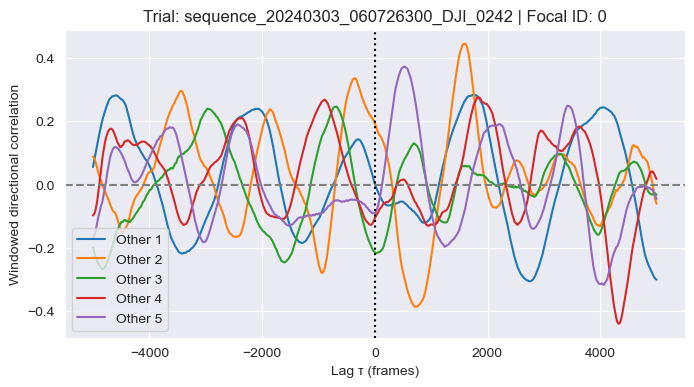

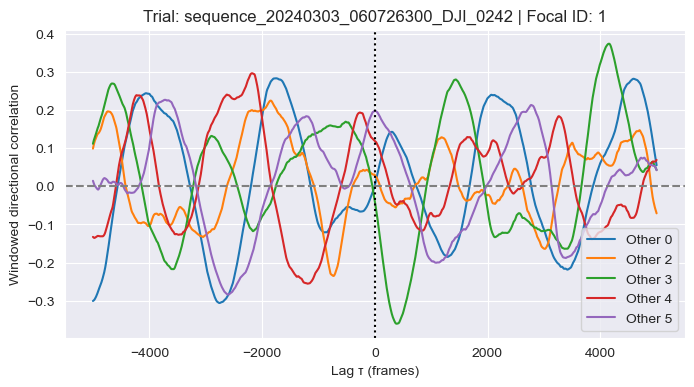

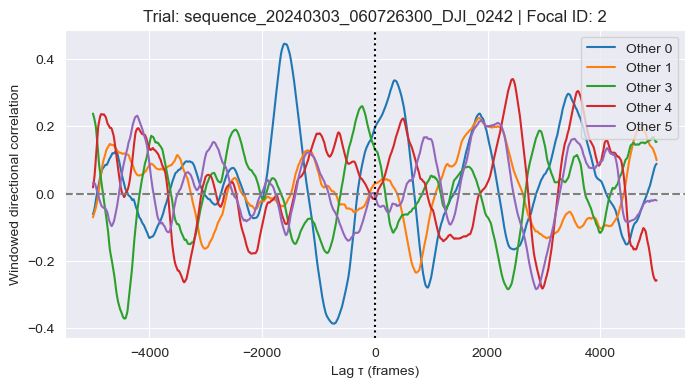

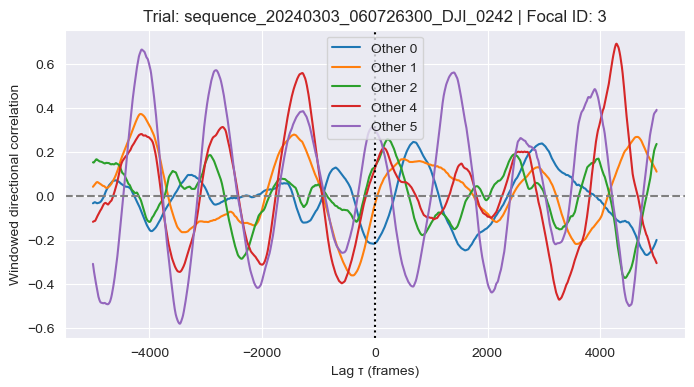

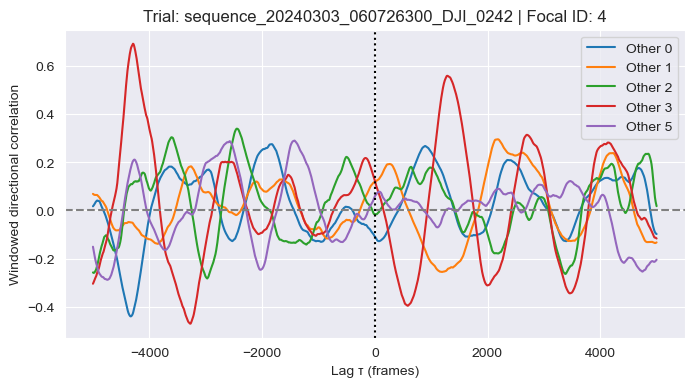

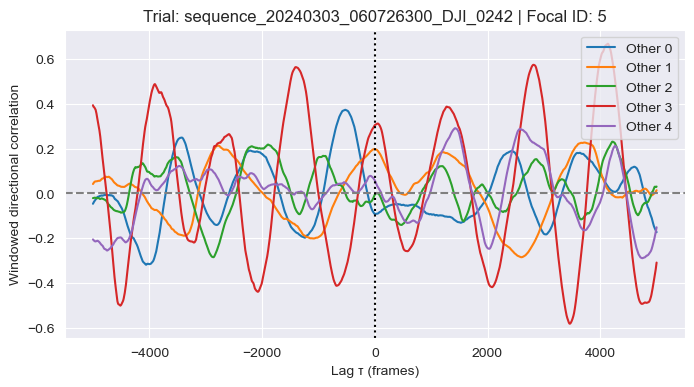

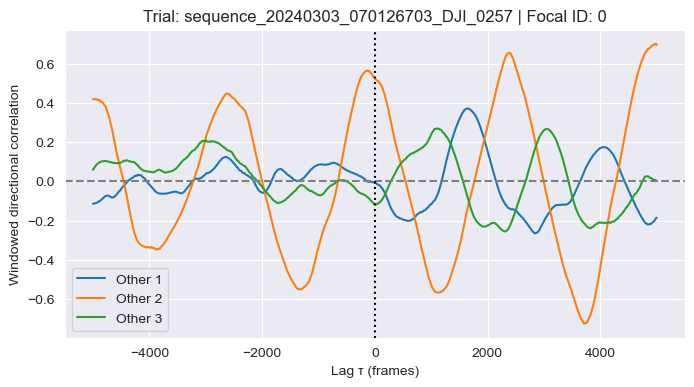

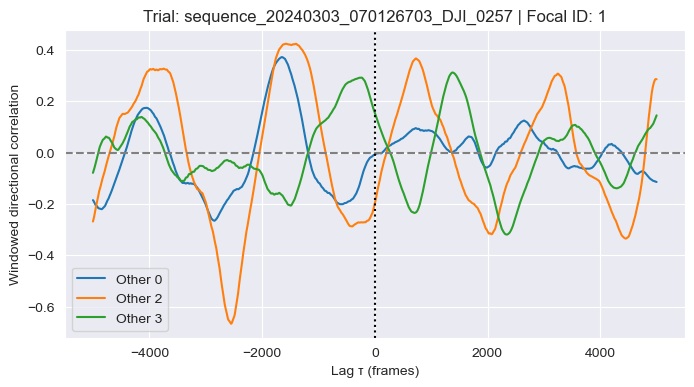

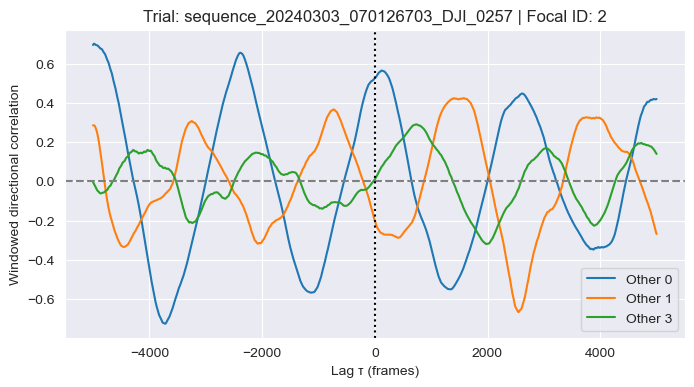

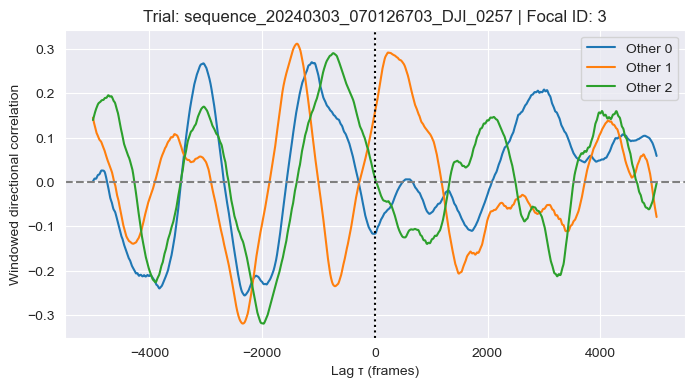

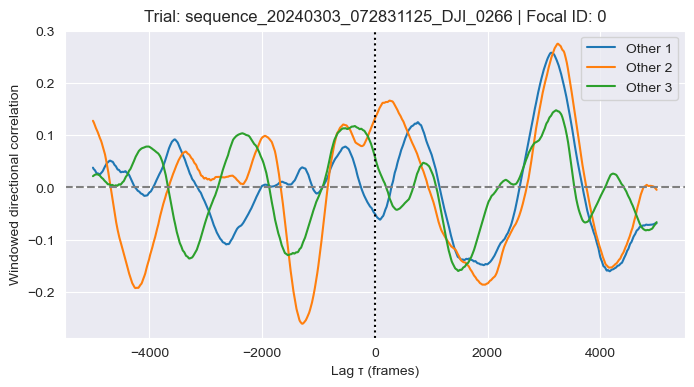

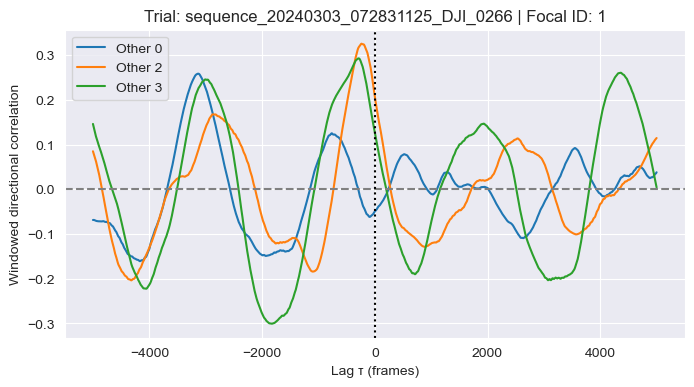

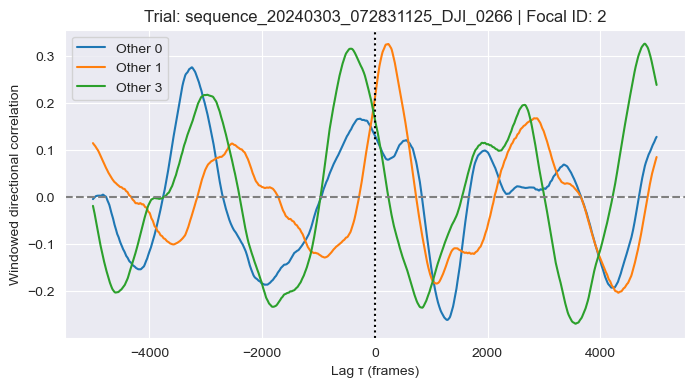

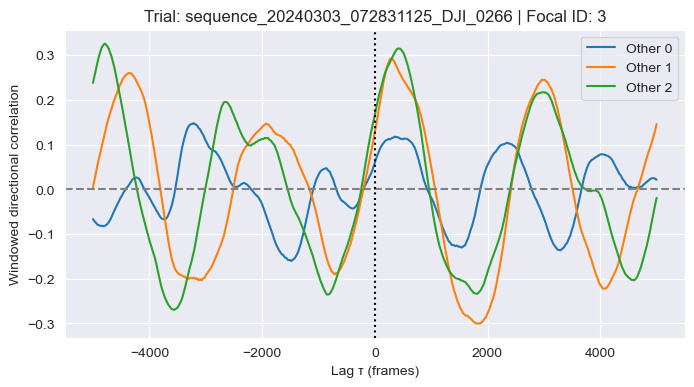

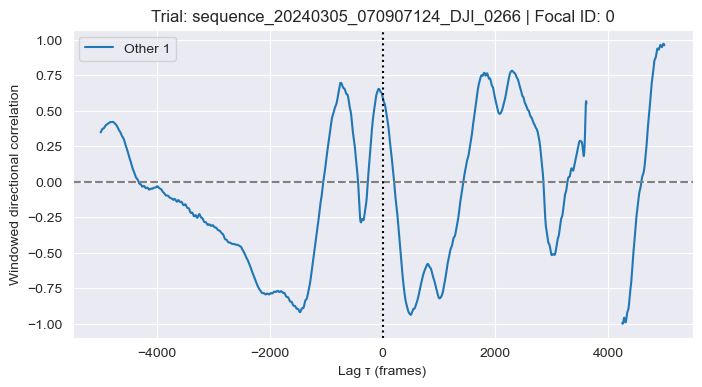

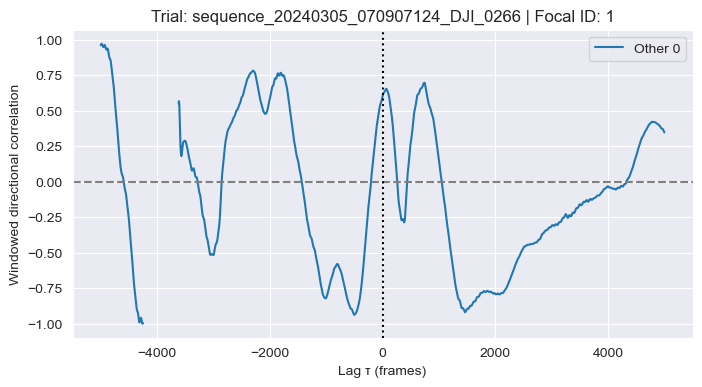

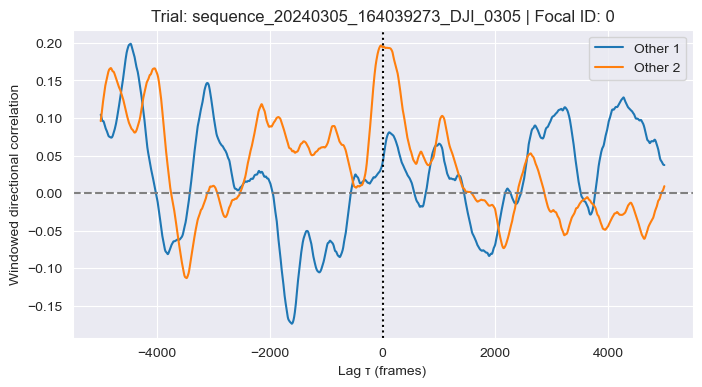

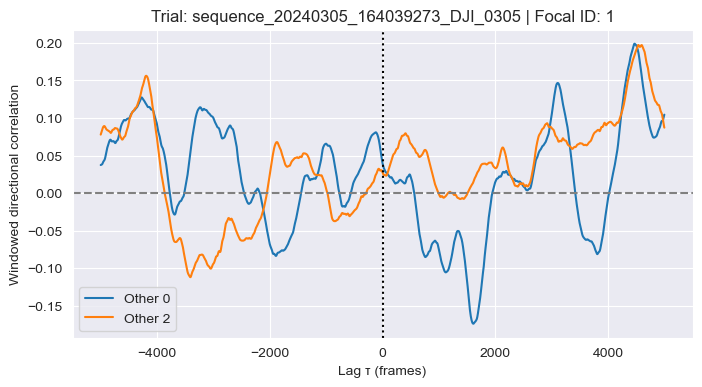

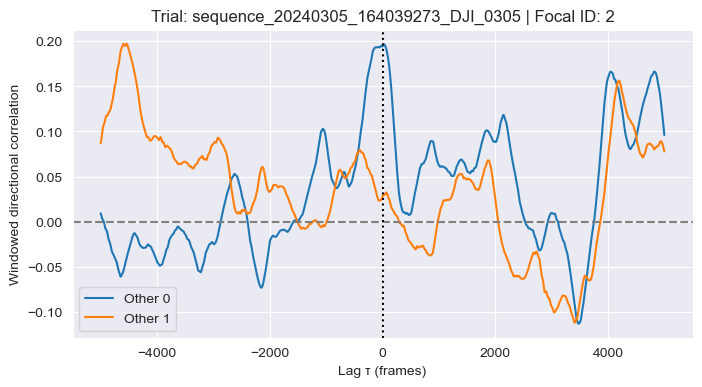

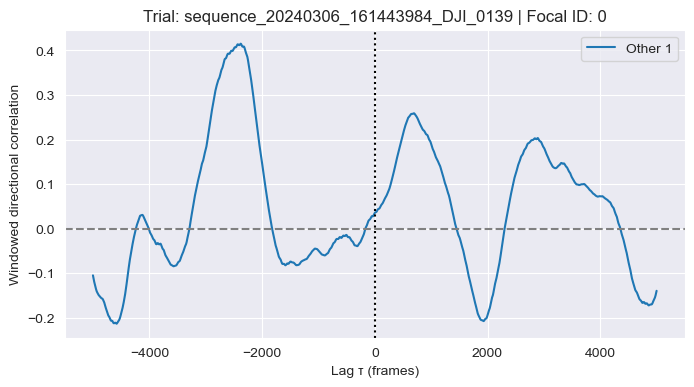

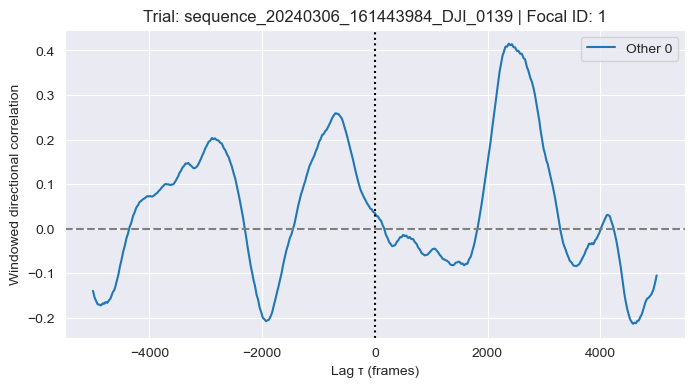

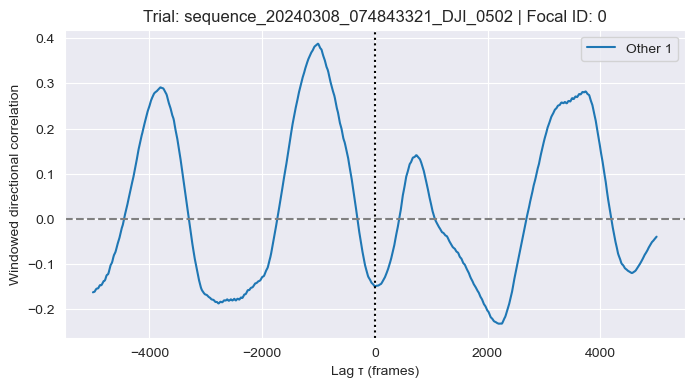

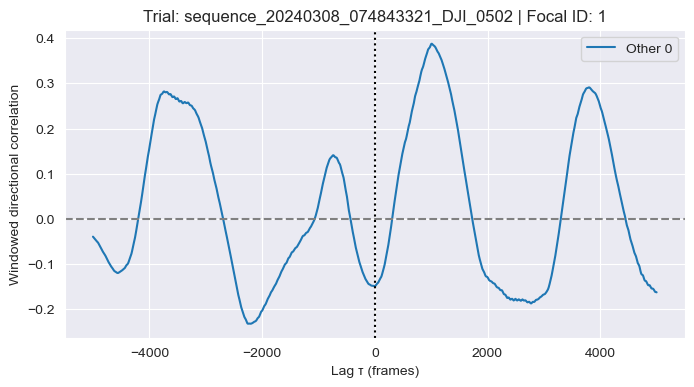

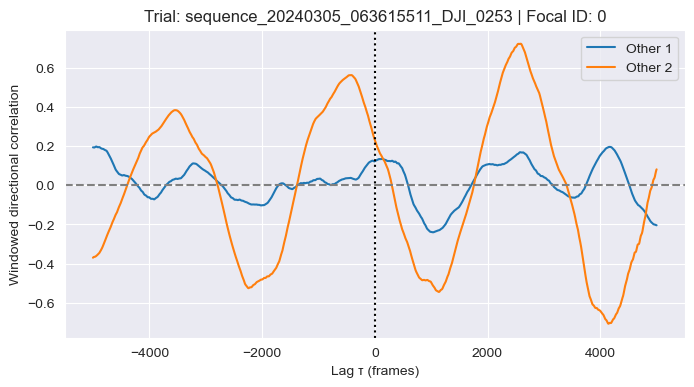

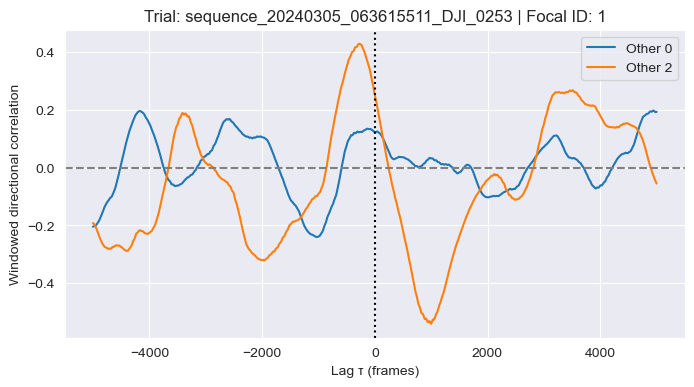

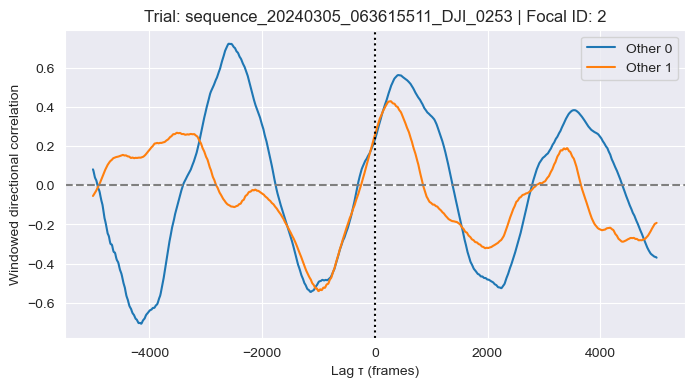

In [33]:
# tau_df should have columns: ['Trial', 'focal', 'other', 'tau', 'correlation_windowed']
for trial in tau_df['Trial'].unique():
    df_trial = tau_df[tau_df['Trial'] == trial]

    for fid in df_trial['focal'].unique():
        df_focal = df_trial[df_trial['focal'] == fid]
        plt.figure(figsize=(8,4))
        for oid in df_focal['other'].unique():
            df_pair = df_focal[df_focal['other'] == oid]
            plt.plot(df_pair['tau'], df_pair['correlation_windowed'], label=f"Other {oid}")

        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='k', linestyle=':')
        plt.xlabel("Lag τ (frames)")
        plt.ylabel("Windowed directional correlation")
        plt.title(f"Trial: {trial} | Focal ID: {fid}")
        plt.legend()
        plt.grid(True)
        plt.show()


In [34]:
# Save sharks_df to HDF5
sharks_output_file = os.path.join(output_folder, "correlation_sharks.h5")
tau_df.to_hdf(sharks_output_file, key='sharks', mode='w')
print(f"Shark data saved to {sharks_output_file}")

Shark data saved to C:/Seafile//BSc_data//processed_data/correlation_sharks.h5


In [36]:
def multi_trial_correlation_windowed_simple(df, trial_col="Trial", frame_col="frame", window=50):
    """
    Compute windowed per-frame directional correlation for all focal IDs vs other IDs,
    across all trials.

    Parameters
    ----------
    df : DataFrame with ['Trial','ID', frame_col, 'vx','vy']
    trial_col : str, name of trial column
    frame_col : str, name of frame column
    window : int, rolling window size

    Returns
    -------
    DataFrame with columns ['Trial','frame','focal','other','correlation_windowed']
    """
    results = []
    for trial in df[trial_col].unique():
        df_trial = df[df[trial_col] == trial]
        ids = df_trial["ID"].unique()

        for fid in ids:
            df_a = df_trial[df_trial["ID"] == fid].sort_values(frame_col)
            for oid in ids:
                if oid == fid:
                    continue
                df_b = df_trial[df_trial["ID"] == oid].sort_values(frame_col)
                corr_df = directional_correlation_windowed_simple(
                    df_a, df_b, window=window, frame_col=frame_col
                )
                corr_df["Trial"] = trial
                corr_df["focal"] = fid
                corr_df["other"] = oid
                results.append(corr_df)

    return pd.concat(results, ignore_index=True)


In [37]:
# Compute windowed per-frame correlations (50-frame window)
corr_df = multi_trial_correlation_windowed_simple(df_vec, window=50, frame_col="frame")

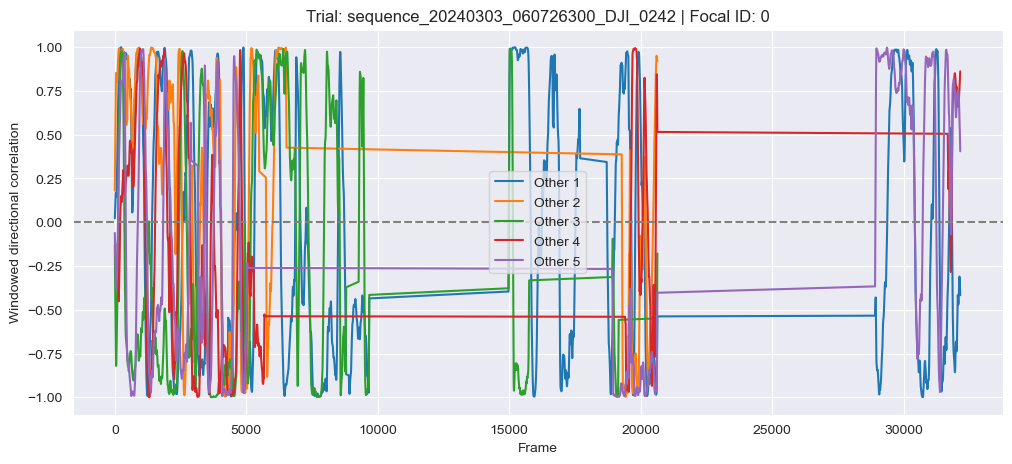

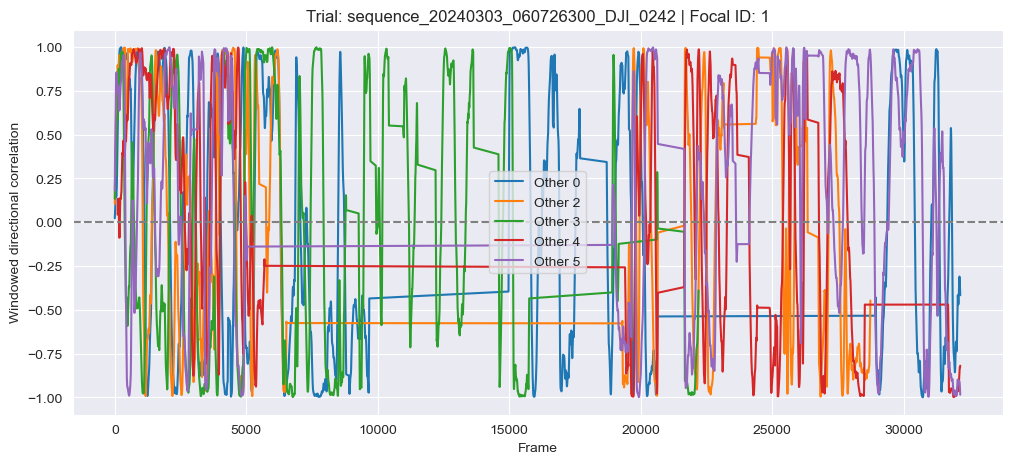

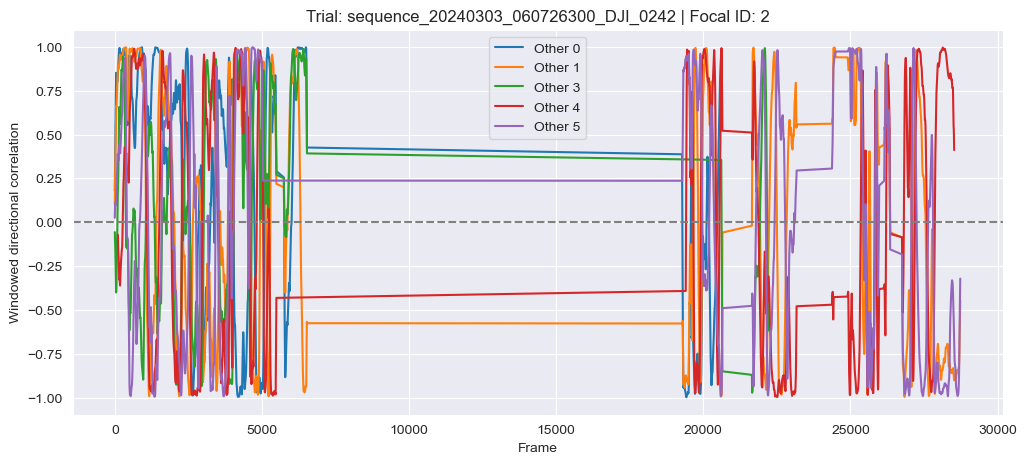

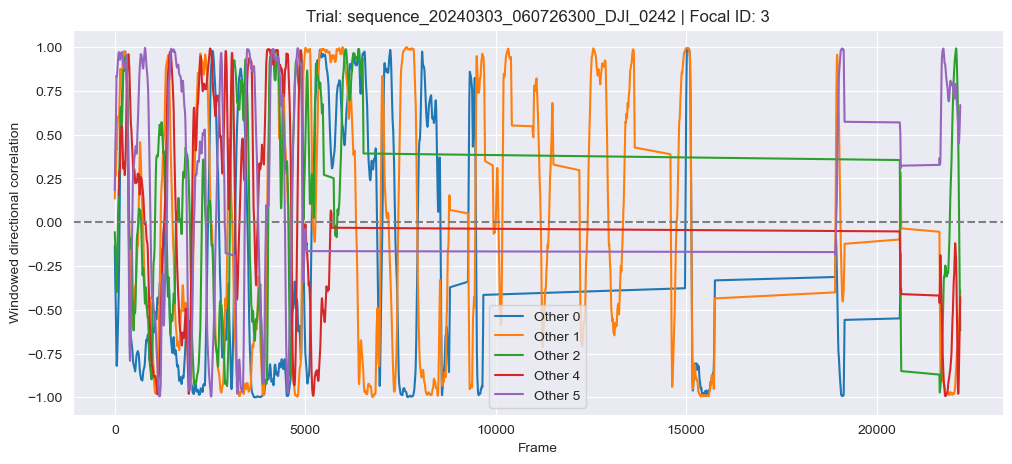

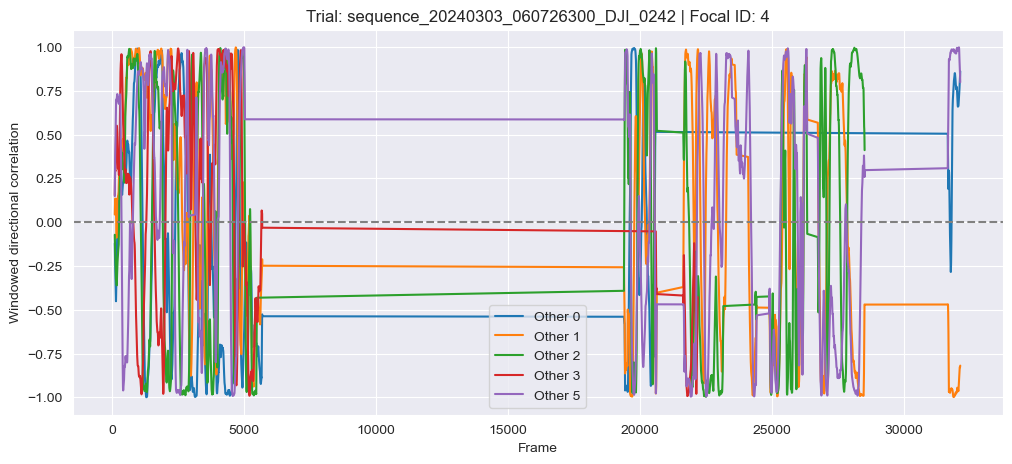

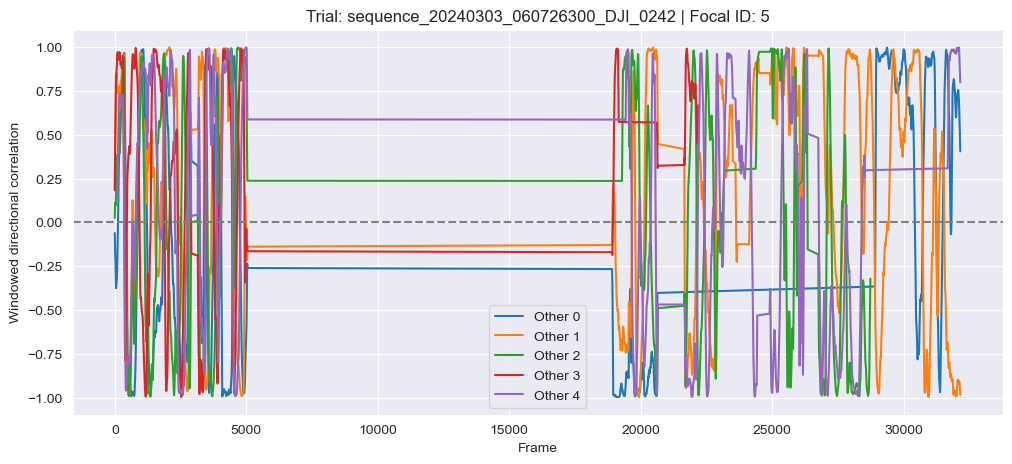

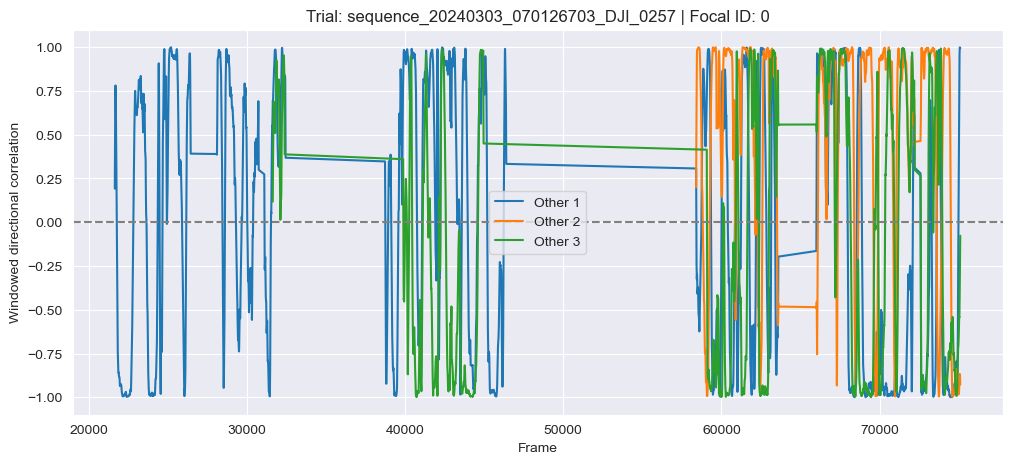

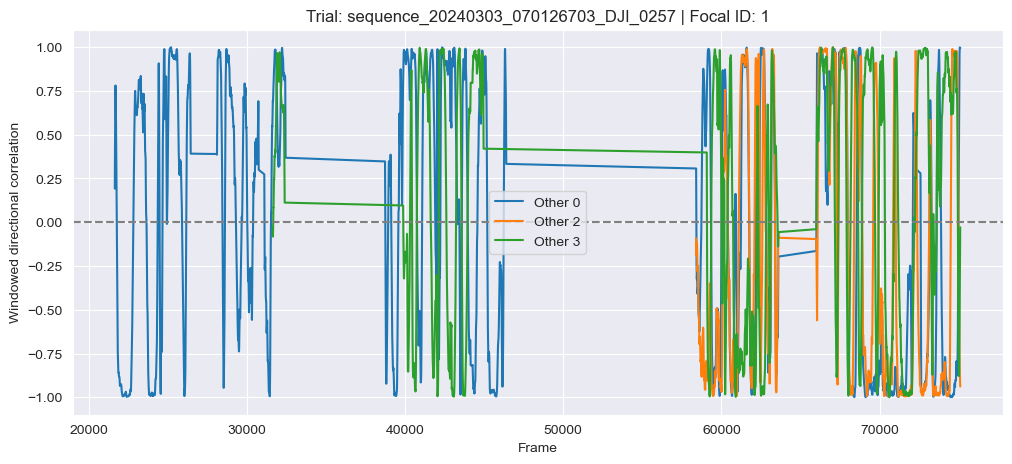

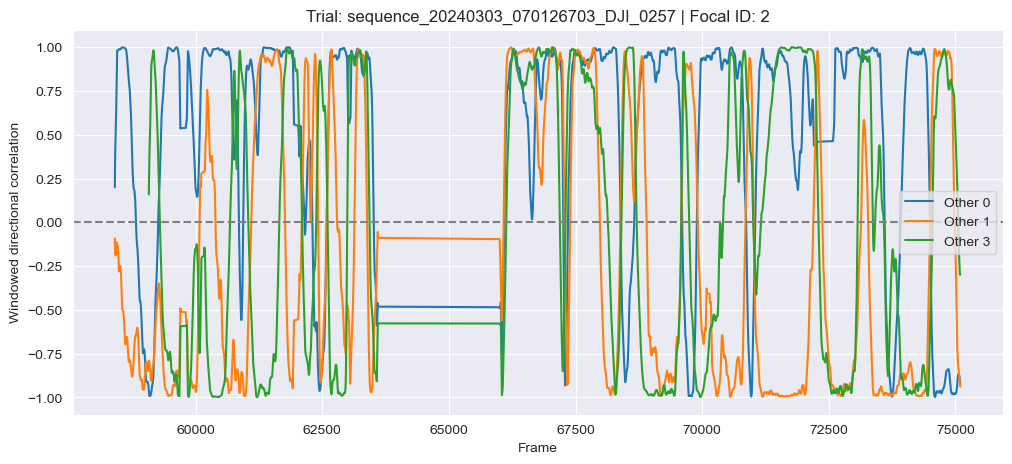

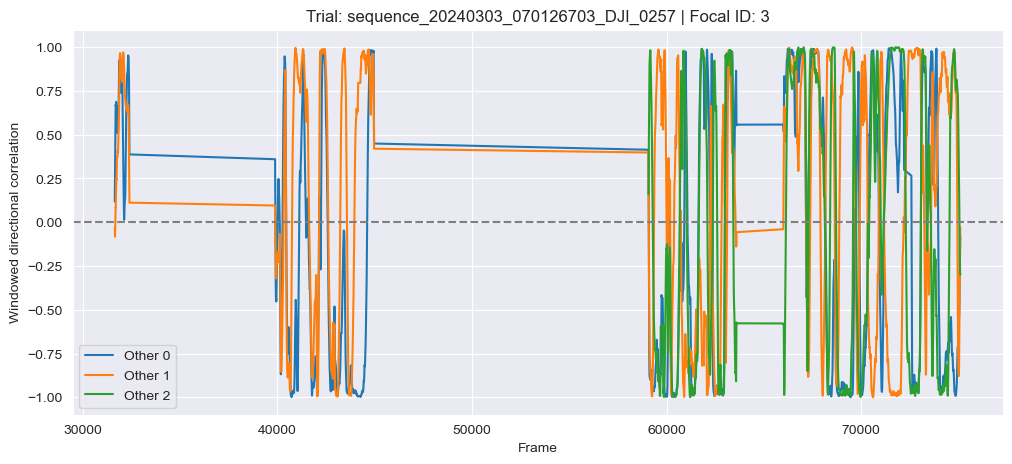

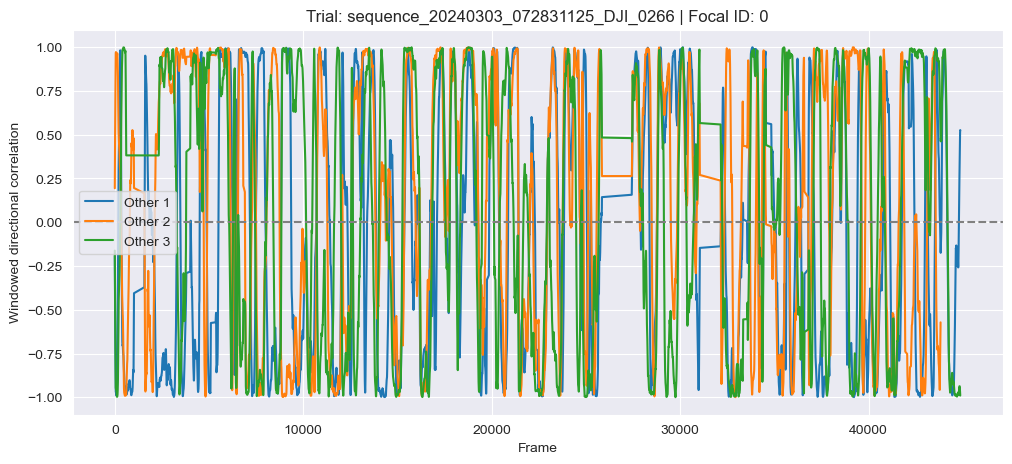

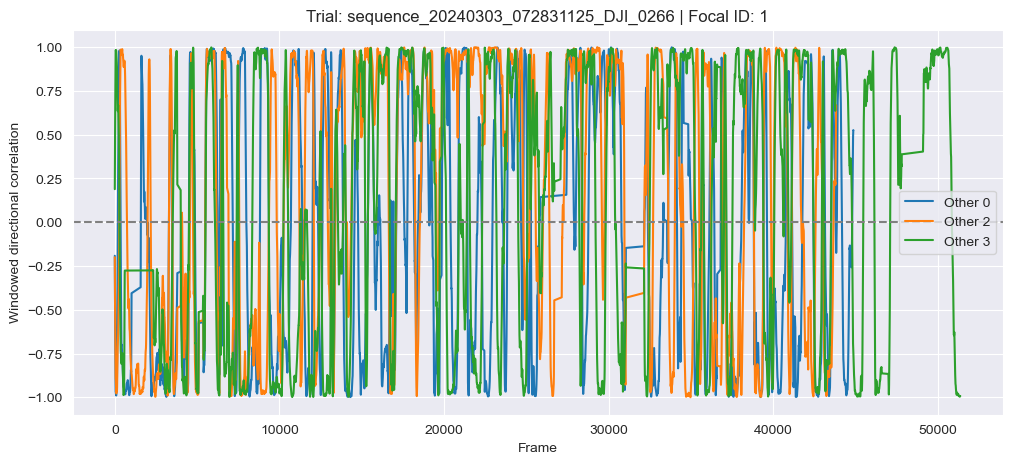

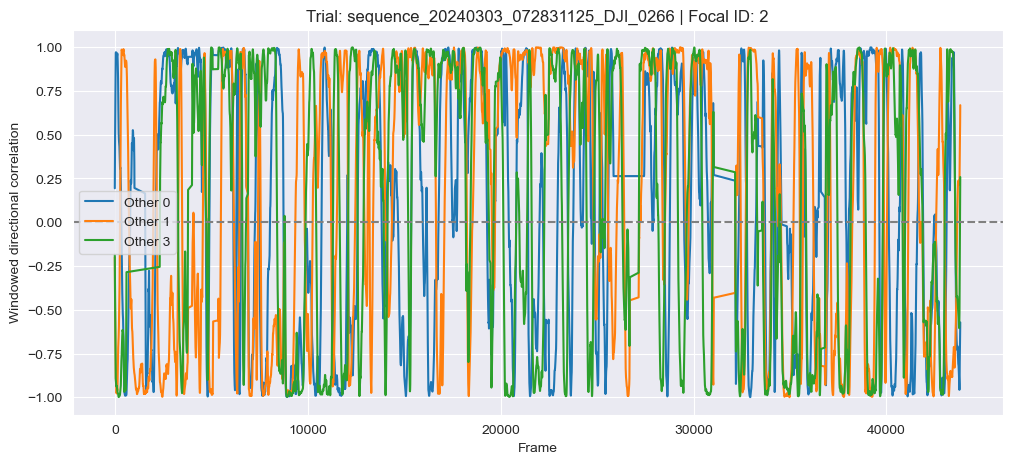

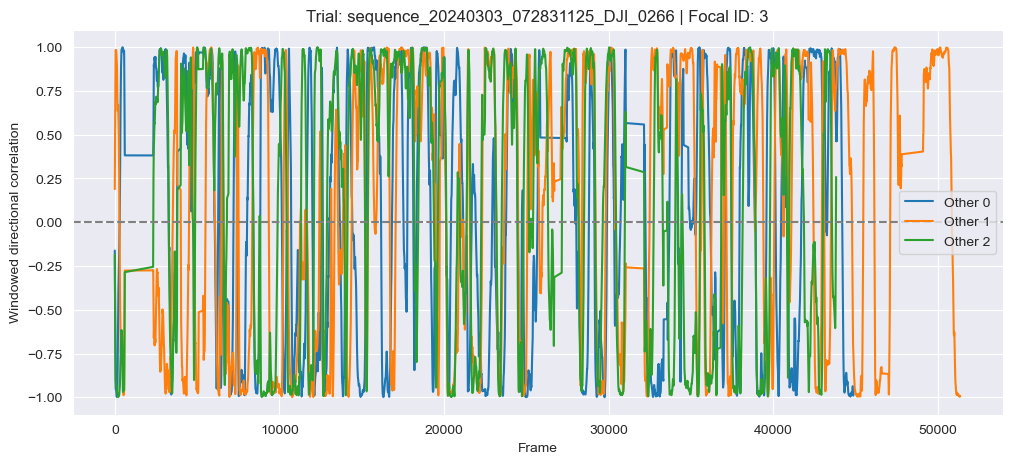

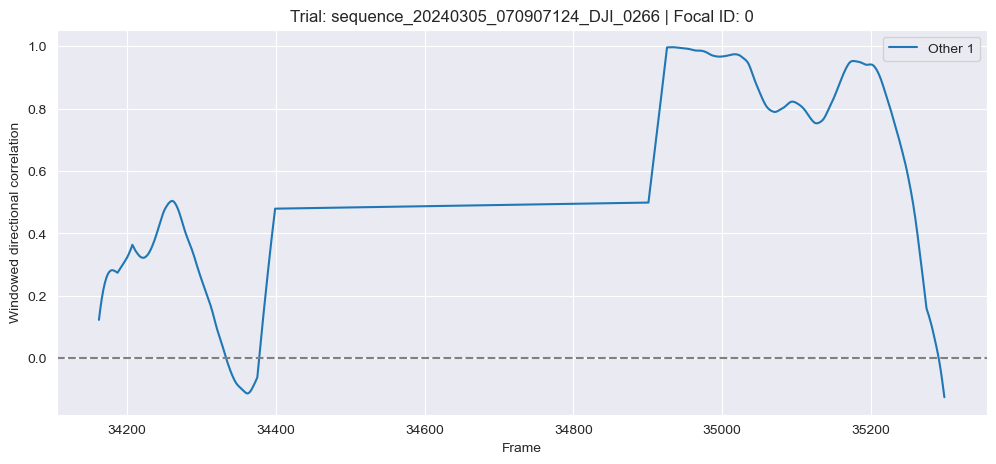

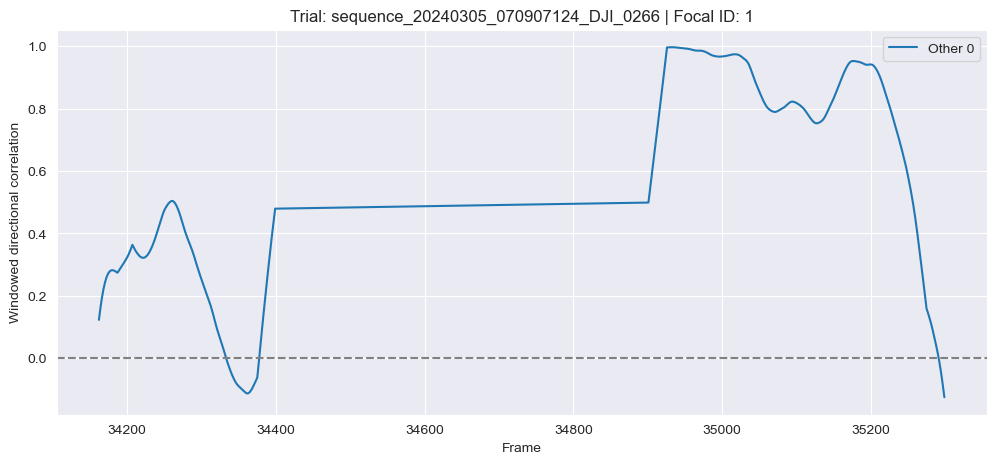

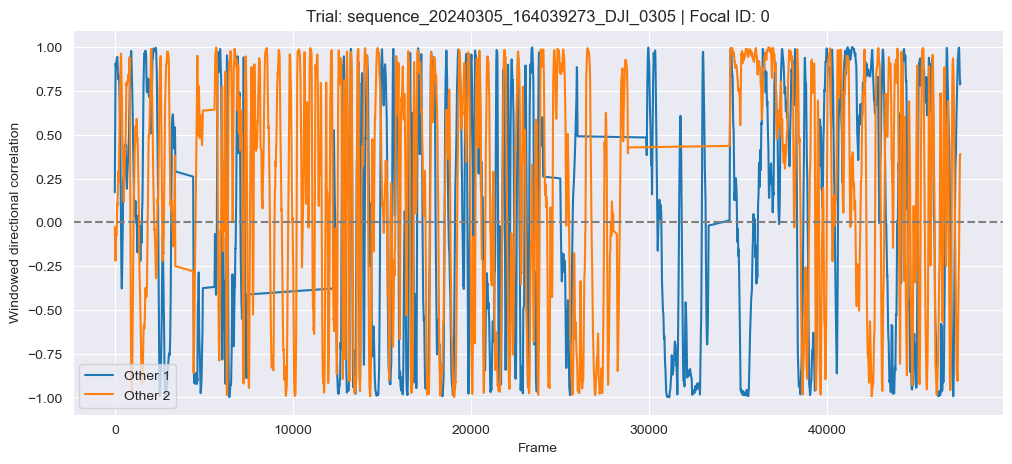

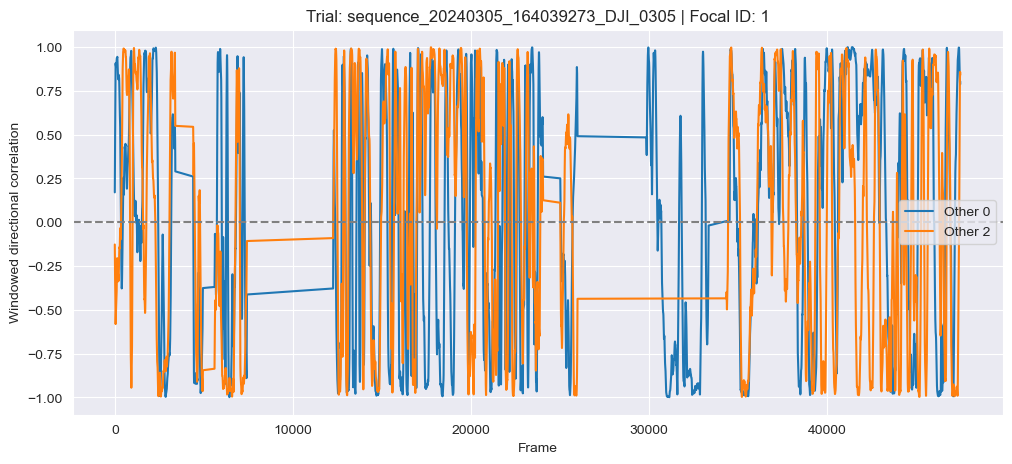

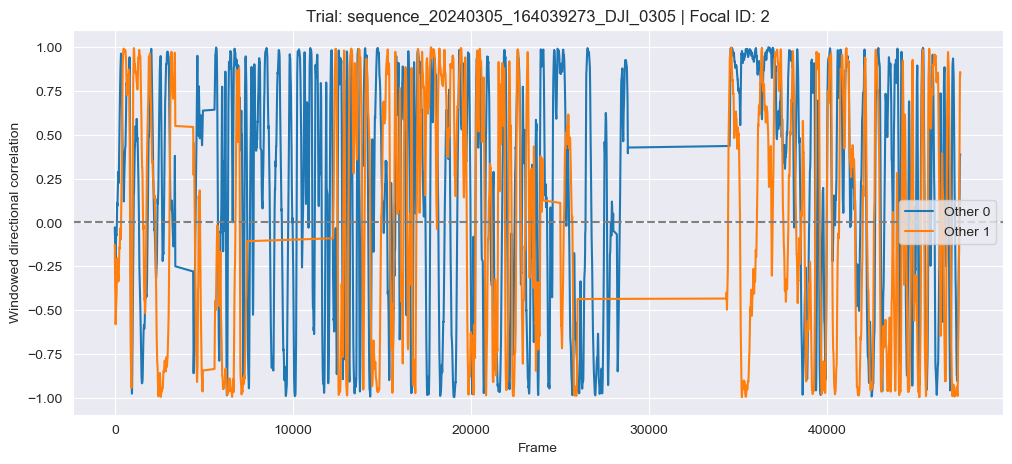

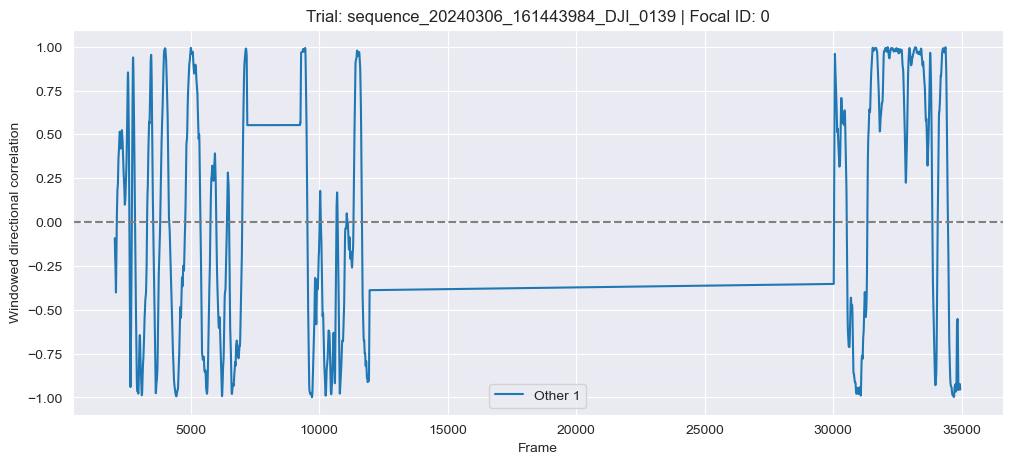

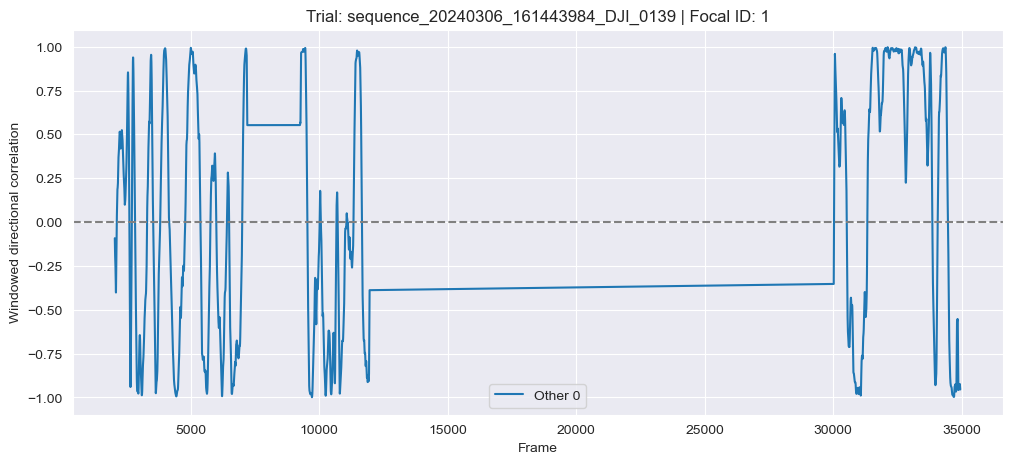

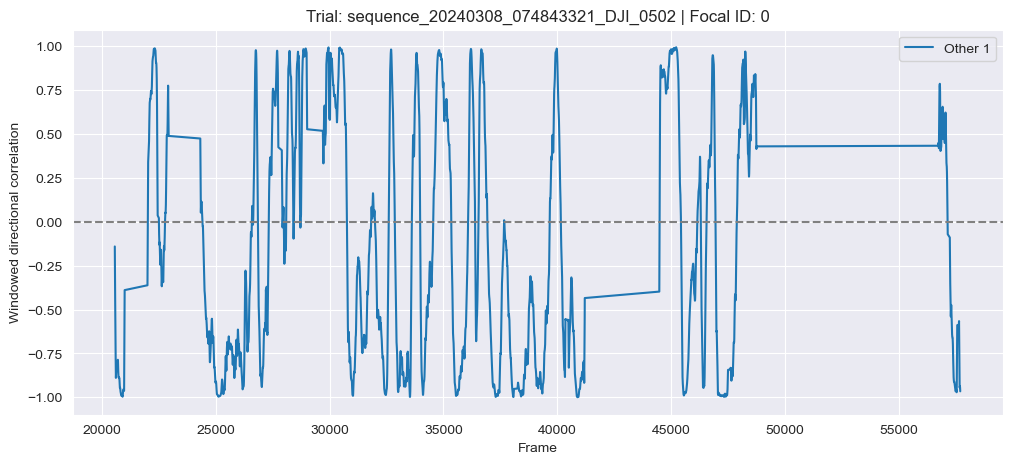

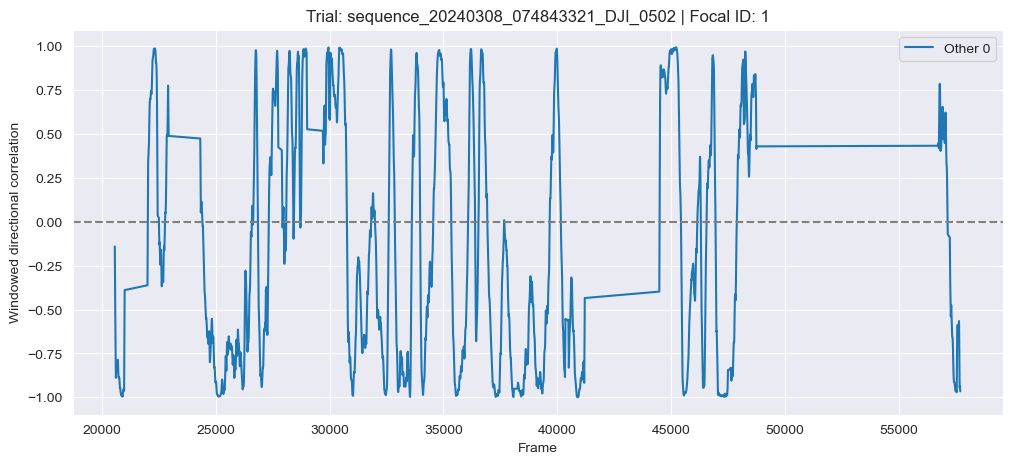

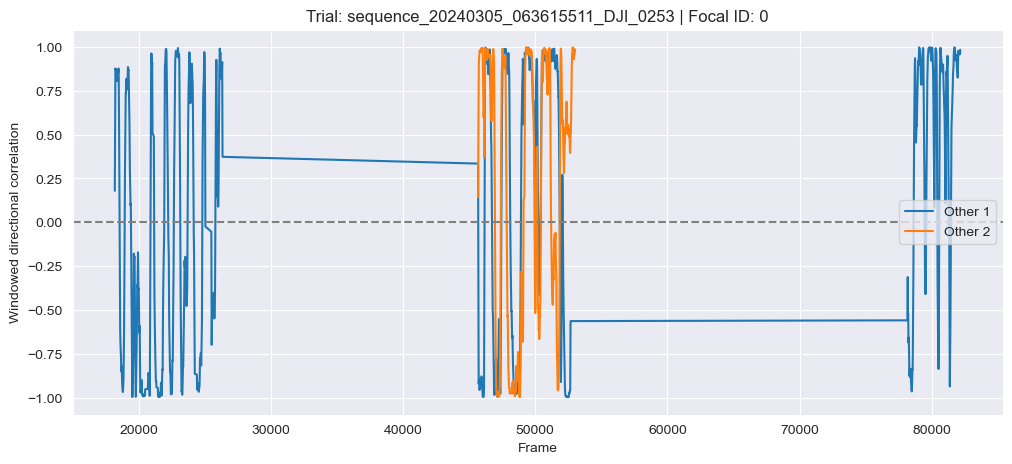

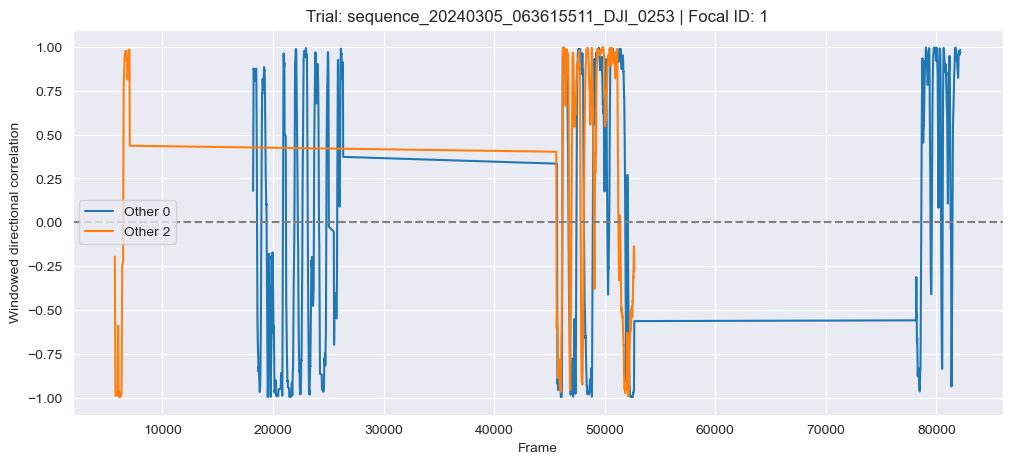

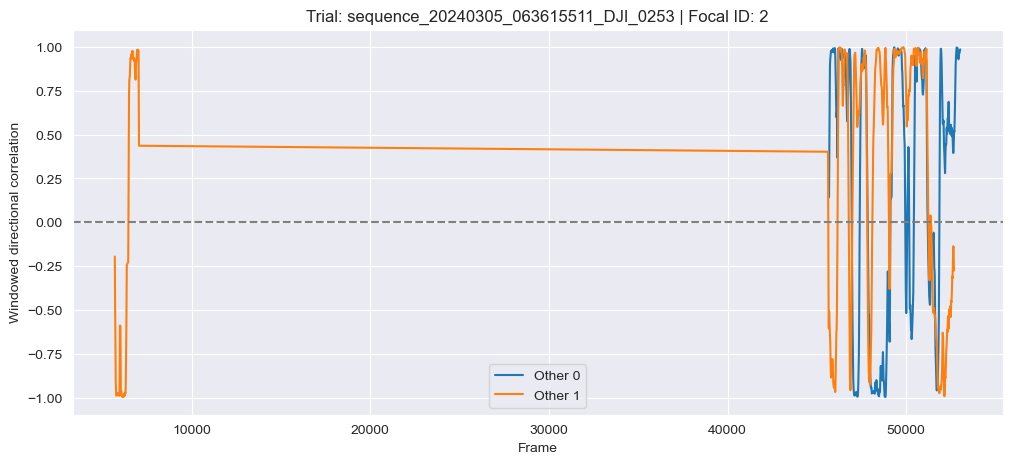

In [39]:
import matplotlib.pyplot as plt

# Plot per trial and per focal ID
for trial in corr_df['Trial'].unique():
    df_trial = corr_df[corr_df['Trial'] == trial]

    for fid in df_trial['focal'].unique():
        df_focal = df_trial[df_trial['focal'] == fid]
        plt.figure(figsize=(12,5))

        for oid in df_focal['other'].unique():
            df_pair = df_focal[df_focal['other'] == oid].sort_values('frame')
            plt.plot(df_pair['frame'], df_pair['correlation_windowed'], label=f"Other {oid}")

        plt.axhline(0, color='gray', linestyle='--')
        plt.xlabel("Frame")
        plt.ylabel("Windowed directional correlation")
        plt.title(f"Trial: {trial} | Focal ID: {fid}")
        plt.legend()
        plt.grid(True)
        plt.show()


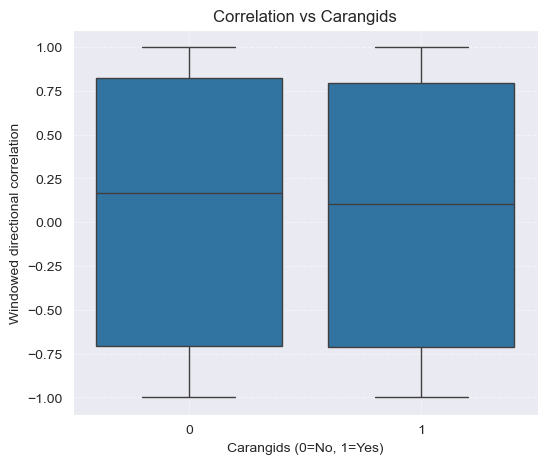

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge carangids info into corr_df (assuming carangids is per-frame)
df_plot = corr_df.merge(
    df_vec[['frame', 'Trial', 'carangids']].drop_duplicates(),
    on='frame',
    how='left'
)

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x='carangids', y='correlation_windowed', data=df_plot)
plt.xlabel("Carangids (0=No, 1=Yes)")
plt.ylabel("Windowed directional correlation")
plt.title("Correlation vs Carangids")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()